In [1]:
!pip -q install kaggle

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from google.colab import files
files.upload()

Saving kaggle (7).json to kaggle (7).json


{'kaggle (7).json': b'{"username":"pranay061020","key":"a82bbe2b1d38c5a3635e2e32d7f0f5ed"}'}

In [6]:
!mkdir -p ~/.kaggle

!cp "kaggle (7).json" ~/.kaggle/kaggle.json

!chmod 600 ~/.kaggle/kaggle.json

In [7]:
!kaggle datasets download -d volkandl/cartoon-classification

Dataset URL: https://www.kaggle.com/datasets/volkandl/cartoon-classification
License(s): CC0-1.0
100% 11.5G/11.5G [07:36<00:00, 27.1MB/s]



In [21]:
import os

path = "/content/cartoon_dataset/cartoon_classification"

for root, dirs, files in os.walk(path):
    print("\nROOT:", root)
    print("DIRS:", dirs[:10])
    print("FILES:", files[:10])

    if len(dirs) > 0:
        break


ROOT: /content/cartoon_dataset/cartoon_classification
DIRS: ['TEST', 'TRAIN']
FILES: []


In [22]:
!ls -lah /content/cartoon_dataset/cartoon_classification

total 16K
drwxr-xr-x  4 root root 4.0K Jun 13 12:30 .
drwxr-xr-x  3 root root 4.0K Jun 13 12:29 ..
drwxr-xr-x 12 root root 4.0K Jun 13 12:30 TEST
drwxr-xr-x 12 root root 4.0K Jun 13 12:32 TRAIN


In [23]:
!find /content/cartoon_dataset/cartoon_classification -maxdepth 3 -type d | head -50

/content/cartoon_dataset/cartoon_classification
/content/cartoon_dataset/cartoon_classification/TEST
/content/cartoon_dataset/cartoon_classification/TEST/pokemon
/content/cartoon_dataset/cartoon_classification/TEST/tom_and_jerry
/content/cartoon_dataset/cartoon_classification/TEST/Gumball
/content/cartoon_dataset/cartoon_classification/TEST/adventure_time
/content/cartoon_dataset/cartoon_classification/TEST/smurfs
/content/cartoon_dataset/cartoon_classification/TEST/Tsubasa
/content/cartoon_dataset/cartoon_classification/TEST/Familyguy
/content/cartoon_dataset/cartoon_classification/TEST/spongebob
/content/cartoon_dataset/cartoon_classification/TEST/catdog
/content/cartoon_dataset/cartoon_classification/TEST/southpark
/content/cartoon_dataset/cartoon_classification/TRAIN
/content/cartoon_dataset/cartoon_classification/TRAIN/pokemon
/content/cartoon_dataset/cartoon_classification/TRAIN/tom_and_jerry
/content/cartoon_dataset/cartoon_classification/TRAIN/Gumball
/content/cartoon_dataset/c

In [24]:
!df -h

Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   44G   64G  41% /
tmpfs            64M     0   64M   0% /dev
shm             5.7G     0  5.7G   0% /dev/shm
/dev/root       2.0G  1.3G  696M  65% /usr/sbin/docker-init
/dev/sda1       114G   45G   70G  40% /kaggle/input
tmpfs           6.4G   22M  6.4G   1% /var/colab
tmpfs           6.4G     0  6.4G   0% /proc/acpi
tmpfs           6.4G     0  6.4G   0% /proc/scsi
tmpfs           6.4G     0  6.4G   0% /sys/firmware
drive            15G  4.2G   11G  28% /content/drive


In [25]:
import os

count = 0

for root, dirs, files in os.walk("/content/cartoon_dataset"):

    image_files = [
        f for f in files
        if f.lower().endswith(
            (".jpg",".jpeg",".png",".bmp")
        )
    ]

    if len(image_files) > 0:
        print("\nIMAGE FOLDER FOUND:")
        print(root)
        print("Images:", len(image_files))

        count += 1

        if count > 20:
            break


IMAGE FOLDER FOUND:
/content/cartoon_dataset/cartoon_classification/TEST/pokemon
Images: 1608

IMAGE FOLDER FOUND:
/content/cartoon_dataset/cartoon_classification/TEST/tom_and_jerry
Images: 2168

IMAGE FOLDER FOUND:
/content/cartoon_dataset/cartoon_classification/TEST/Gumball
Images: 2077

IMAGE FOLDER FOUND:
/content/cartoon_dataset/cartoon_classification/TEST/adventure_time
Images: 1756

IMAGE FOLDER FOUND:
/content/cartoon_dataset/cartoon_classification/TEST/smurfs
Images: 1909

IMAGE FOLDER FOUND:
/content/cartoon_dataset/cartoon_classification/TEST/Tsubasa
Images: 1305

IMAGE FOLDER FOUND:
/content/cartoon_dataset/cartoon_classification/TEST/Familyguy
Images: 1788

IMAGE FOLDER FOUND:
/content/cartoon_dataset/cartoon_classification/TEST/spongebob
Images: 1957

IMAGE FOLDER FOUND:
/content/cartoon_dataset/cartoon_classification/TEST/catdog
Images: 2179

IMAGE FOLDER FOUND:
/content/cartoon_dataset/cartoon_classification/TEST/southpark
Images: 1363

IMAGE FOLDER FOUND:
/content/car

In [26]:
!find /content/cartoon_dataset -type d | head -100

/content/cartoon_dataset
/content/cartoon_dataset/cartoon_classification
/content/cartoon_dataset/cartoon_classification/TEST
/content/cartoon_dataset/cartoon_classification/TEST/pokemon
/content/cartoon_dataset/cartoon_classification/TEST/tom_and_jerry
/content/cartoon_dataset/cartoon_classification/TEST/Gumball
/content/cartoon_dataset/cartoon_classification/TEST/adventure_time
/content/cartoon_dataset/cartoon_classification/TEST/smurfs
/content/cartoon_dataset/cartoon_classification/TEST/Tsubasa
/content/cartoon_dataset/cartoon_classification/TEST/Familyguy
/content/cartoon_dataset/cartoon_classification/TEST/spongebob
/content/cartoon_dataset/cartoon_classification/TEST/catdog
/content/cartoon_dataset/cartoon_classification/TEST/southpark
/content/cartoon_dataset/cartoon_classification/TRAIN
/content/cartoon_dataset/cartoon_classification/TRAIN/pokemon
/content/cartoon_dataset/cartoon_classification/TRAIN/tom_and_jerry
/content/cartoon_dataset/cartoon_classification/TRAIN/Gumball
/

In [31]:
import tensorflow as tf

TRAIN_PATH = "/content/cartoon_dataset/cartoon_classification/TRAIN"

TEST_PATH = "/content/cartoon_dataset/cartoon_classification/TEST"

IMG_SIZE = (64,64)

BATCH_SIZE = 16

full_train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

Found 119617 files belonging to 10 classes.


In [32]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 18110 files belonging to 10 classes.


In [33]:
class_names = full_train_ds.class_names

print(class_names)

num_classes = len(class_names)

print("Number of Classes:",num_classes)

['Familyguy', 'Gumball', 'Tsubasa', 'adventure_time', 'catdog', 'pokemon', 'smurfs', 'southpark', 'spongebob', 'tom_and_jerry']
Number of Classes: 10


In [35]:
dataset_size = tf.data.experimental.cardinality(
    full_train_ds
).numpy()
print("Total Batches:",dataset_size)

Total Batches: 7477


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import models

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [37]:
train_size = int(dataset_size * 0.8)
train_ds = full_train_ds.take(train_size)

val_ds = full_train_ds.skip(train_size)

print("Train Batches:",train_size)
print("Validation Batches:",dataset_size - train_size)

Train Batches: 5981
Validation Batches: 1496


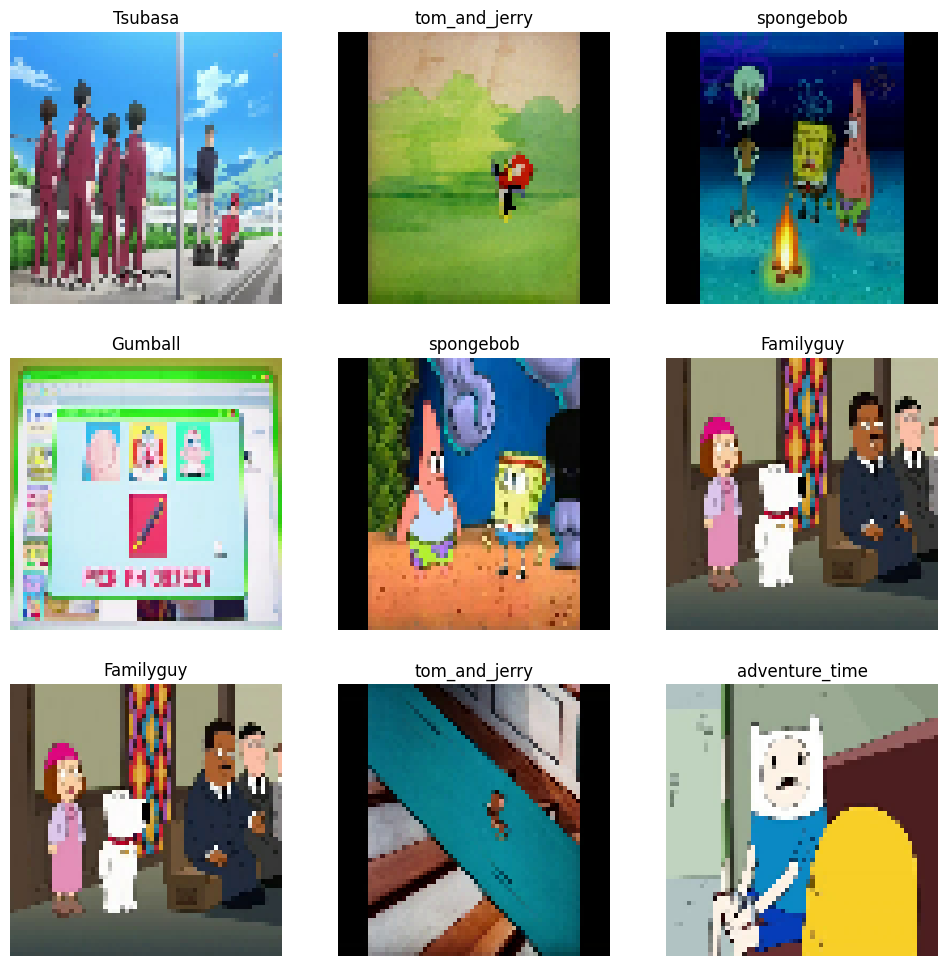

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,12))

for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3,3,i+1)
    plt.imshow(
        images[i].numpy().astype('uint8')
    )
    plt.title(
        class_names[labels[i]]
    )
    plt.axis('off')

plt.show()

In [39]:
for images, labels in train_ds.take(1):

    print("Images Shape:",
          images.shape)

    print("Labels Shape:",
          labels.shape)

Images Shape: (16, 64, 64, 3)
Labels Shape: (16,)


In [40]:
normalization_layer = tf.keras.layers.Rescaling(
    1./255
)

In [41]:
normalized_ds = train_ds.map(
    lambda x,y:
    (normalization_layer(x),y)
)

In [42]:
import numpy as np

for image_batch,label_batch in normalized_ds.take(1):

    first_image = image_batch[0]

    print(
        "Min:",
        np.min(first_image)
    )

    print(
        "Max:",
        np.max(first_image)
    )

Min: 0.0
Max: 1.0


In [44]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.1),

    layers.RandomZoom(0.1)

])

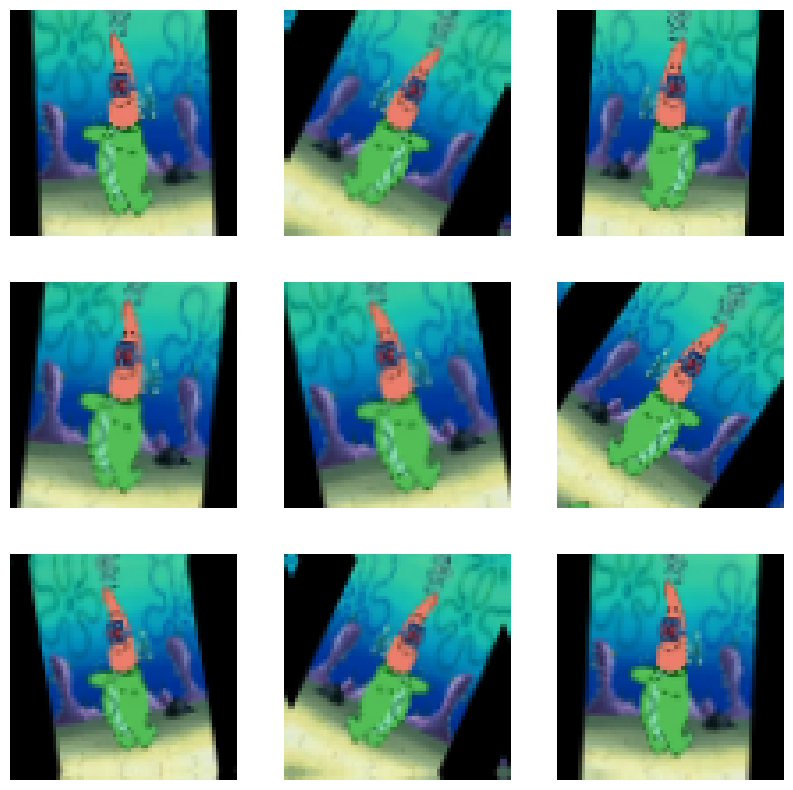

In [45]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):

    image = images[0]

    for i in range(9):

        aug = data_augmentation(
            tf.expand_dims(image,0)
        )

        ax = plt.subplot(3,3,i+1)

        plt.imshow(
            aug[0].numpy().astype("uint8")
        )

        plt.axis("off")

plt.show()

In [46]:
for images, labels in train_ds.take(1):
  sample_image = images[0].numpy()
  break

In [48]:
gray = tf.image.rgb_to_grayscale(
    sample_image
)

gray = tf.squeeze(gray)

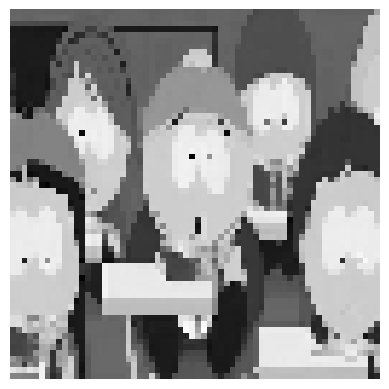

In [49]:
plt.imshow(
    gray,
    cmap='gray'
)

plt.axis("off")

plt.show()

In [51]:
kernel = np.array([

    [-1,-1,-1],

    [-1, 8,-1],

    [-1,-1,-1]

])

In [52]:
from scipy.signal import convolve2d

feature_map = convolve2d(
    gray,
    kernel,
    mode='same'
)

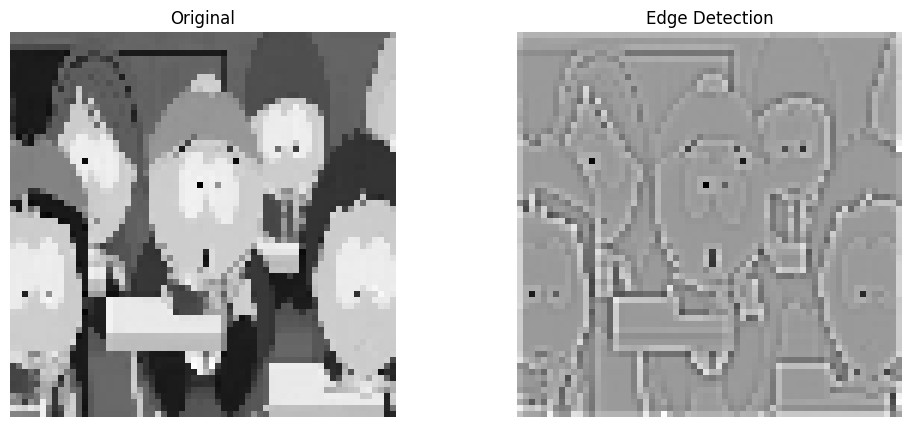

In [53]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.imshow(
    gray,
    cmap='gray'
)

plt.title("Original")

plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(
    feature_map,
    cmap='gray'
)

plt.title("Edge Detection")

plt.axis("off")

plt.show()

#POOLING

In [54]:
pool_layer = tf.keras.layers.MaxPooling2D(
    pool_size=(2,2)
)

In [55]:
sample = tf.expand_dims(
    sample_image,
    axis=0
)

pooled = pool_layer(sample)

In [56]:
print(
    "Original:",
    sample.shape
)

print(
    "Pooled:",
    pooled.shape
)

Original: (1, 64, 64, 3)
Pooled: (1, 32, 32, 3)


In [57]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache()

train_ds = train_ds.shuffle(1000)

train_ds = train_ds.prefetch(AUTOTUNE)

val_ds = val_ds.cache().prefetch(
    AUTOTUNE
)

test_ds = test_ds.cache().prefetch(
    AUTOTUNE
)

In [58]:
cnn_model = models.Sequential([
    layers.Rescaling(
        1./255,
        input_shape=(64,64,3)
    ),
    layers.Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu'
    ),
    layers.MaxPooling2D(
        pool_size=(2,2)
    ),
    layers.Conv2D(
        filters=128,
        kernel_size=(3,3),
        activation='relu'
    ),
    layers.Flatten(),

    layers.Dense(
        128,
        activation='relu'
    ),
    layers.Dense(
        len(class_names),
        activation='softmax'
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [59]:
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 128)    │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 107648)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    13,779,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,818,250 (52.71 MB)

 Trainable params: 13,818,250 (52.71 MB)

 Non-trainable params: 0 (0.00 B)

In [60]:
cnn_model.layers[1].count_params()

896

In [61]:
cnn_model.compile(
    optimizer='adam',
    loss = 'sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [62]:
early_stop = tf.keras.callbacks.EarlyStopping(

    monitor='val_loss',

    patience=3,

    restore_best_weights=True
)

In [64]:
from PIL import Image
import os

bad_images = []

DATASET_PATH = "/content/cartoon_dataset/cartoon_classification/TRAIN"

for root, dirs, files in os.walk(DATASET_PATH):

    for file in files:

        if file.lower().endswith(
            (".jpg",".jpeg",".png")
        ):

            path = os.path.join(root,file)

            try:
                img = Image.open(path)
                img.verify()

            except Exception:
                bad_images.append(path)

print("Corrupted Images:", len(bad_images))

Corrupted Images: 0


In [65]:
for img in bad_images:
    os.remove(img)

print("Deleted",len(bad_images),"corrupted images")

Deleted 0 corrupted images


In [ ]:
for img in bad_images[:20]:
    print(img)

In [66]:
history = cnn_model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=10,

    callbacks=[early_stop]
)

Epoch 1/10
2687/5981 ━━━━━━━━━━━━━━━━━━━━ 25:31 465ms/step - accuracy: 0.9917 - loss: 0.0303

KeyboardInterrupt: 